# Experiment 2: Learning Curve Analysis
- Train models on 25%, 50%, 75%, and 100% of training data
- Plot performance vs. training size
- Analyze: At what size do neural models surpass baselines? Does the Transformer benefit more from additional data than the LSTM?
## Imports and partition data


In [1]:
import os
import time
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

from src.preprocessing import get_preprocessed_data

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Create directories
os.makedirs('figures', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Load data
train_df, val_df, test_df, id2label, label2id = get_preprocessed_data()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
print(f"\nEvasion label distribution:")
print(train_df['evasion_label'].value_counts())

Train: 2758, Val: 690, Test: 308

Evasion label distribution:
evasion_label
5    841
4    565
7    390
6    309
3    305
2    116
0     95
1     74
8     63
Name: count, dtype: int64


In [2]:
# Create contextual features
for df in [train_df, val_df, test_df]:
    df['sub_q_context'] = df['question'].fillna('') + " [SEP] " + df['interview_answer'].fillna('')
    

print("Features prepared!")
print(f"Text feature: sub_q_context")

Features prepared!
Text feature: sub_q_context


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Helper functions

In [4]:
# ============================
# Helpers: memory / params
# ============================
def reset_gpu_memory():
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def gpu_memory_mb():
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / 1024 ** 2
    return 0.0

def count_parameters(model):
    if hasattr(model, "parameters"):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    elif hasattr(model, "coef_"):  # sklearn linear
        return model.coef_.size + (model.intercept_.size if model.intercept_ is not None else 0)
    return 0

def set_all_seeds(seed=SEED):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## Config

In [5]:
# ============================
# Config (keep consistent)
# ============================
SIZES = [0.25, 0.50, 0.75, 1.00]

# Baseline
BASELINE_MAX_ITER = 1000

# RNN tokenization (simple word-index like your Experiment 1)
MAX_VOCAB   = 15_000
MAX_SEQ_LEN = 128
EMBED_DIM   = 128
HIDDEN_DIM  = 128
NUM_LAYERS  = 1
BATCH_SIZE  = 32
RNN_EPOCHS  = 25          
LR_RNN      = 1e-3
DROPOUT     = 0.3       

# BERT
MODEL_NAME   = "bert-base-uncased"
BERT_EPOCHS  = 20          # learning curves: keep small (change if you want)
BERT_BATCH   = 16
LR_BERT      = 2e-5
MAX_LEN_BERT = 128

## Subsample

In [6]:
# ============================
# Subsample utility
# ============================
def subsample_df(df, frac, seed=SEED):
    if frac >= 1.0:
        return df.copy().reset_index(drop=True)
    return df.sample(frac=frac, random_state=seed).reset_index(drop=True)


## Baseline

In [7]:
# ============================
# Baseline trainer
# ============================
def train_eval_baseline(train_sub, val_df):
    set_all_seeds(SEED)
    baseline_pipeline = make_pipeline(
        CountVectorizer(ngram_range=(1, 2), stop_words="english"),
        LogisticRegression(max_iter=BASELINE_MAX_ITER, random_state=SEED),
    )

    t0 = time.time()
    baseline_pipeline.fit(train_sub["sub_q_context"], train_sub["evasion_label"])
    train_time = time.time() - t0

    t0 = time.time()
    preds = baseline_pipeline.predict(val_df["sub_q_context"])
    infer_time = time.time() - t0

    f1 = f1_score(val_df["evasion_label"], preds, average="macro")
    params = count_parameters(baseline_pipeline.named_steps["logisticregression"])

    return {
        "Model": "Baseline (CountVec+LogReg)",
        "Train Size": len(train_sub),
        "Train Frac": None,
        "Val Macro F1": f1,
        "Train Time (s)": train_time,
        "Infer Speed (samples/s)": len(val_df) / max(infer_time, 1e-9),
        "GPU Mem (MB)": 0.0,
        "Parameters": params,
    }

## RNN

In [8]:
# ============================
# RNN vocabulary + dataset
# ============================
def build_vocab(texts, max_vocab=MAX_VOCAB):
    counter = Counter(w for text in texts for w in str(text).lower().split())
    vocab = {"<pad>": 0, "<unk>": 1}
    for word, _ in counter.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    return vocab

def encode_texts(texts, vocab, max_len=MAX_SEQ_LEN):
    unk = vocab["<unk>"]
    out = []
    for text in texts:
        ids = [vocab.get(w, unk) for w in str(text).lower().split()][:max_len]
        ids += [0] * (max_len - len(ids))
        out.append(ids)
    return torch.tensor(out, dtype=torch.long)

class TextDatasetRNN(Dataset):
    def __init__(self, texts, labels, vocab):
        self.x = encode_texts(texts.tolist(), vocab)
        self.y = torch.tensor(labels.tolist(), dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.x[i], self.y[i]

### GRU/LSTM

In [9]:
# ============================
# Models: UniGRU / UniLSTM (same as your Experiment 1)
# ============================
class UniGRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attn = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.gru(emb)                          # (B, L, H)
        weights = torch.softmax(self.attn(out), dim=1)  # (B, L, 1)
        ctx = (out * weights).sum(dim=1)                # (B, H)
        return self.classifier(ctx)

class UniLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, num_classes, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=False,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attn = nn.Linear(hidden_dim, 1)
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes),
        )

    def forward(self, x):
        emb = self.embedding(x)
        out, _ = self.lstm(emb)
        weights = torch.softmax(self.attn(out), dim=1)
        ctx = (out * weights).sum(dim=1)
        return self.classifier(ctx)


In [10]:
def train_eval_rnn(model_name, model, train_loader, val_loader, val_df_len, epochs=RNN_EPOCHS, lr=LR_RNN):
    set_all_seeds(SEED)
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    reset_gpu_memory()
    t0 = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    train_time = time.time() - t0
    mem_mb = gpu_memory_mb()

    # val inference
    model.eval()
    all_preds, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for xb, yb in val_loader:
            logits = model(xb.to(device))
            preds = logits.argmax(dim=1).cpu().numpy().tolist()
            all_preds.extend(preds)
            all_labels.extend(yb.numpy().tolist())
    infer_time = time.time() - t0

    f1 = f1_score(all_labels, all_preds, average="macro")
    return {
        "Model": model_name,
        "Val Macro F1": f1,
        "Train Time (s)": train_time,
        "Infer Speed (samples/s)": val_df_len / max(infer_time, 1e-9),
        "GPU Mem (MB)": mem_mb,
        "Parameters": count_parameters(model),
    }

## BERT

In [11]:
# ============================
# BERT dataset + trainer
# ============================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class EvasionDatasetBERT(Dataset):
    def __init__(self, texts, labels, max_length=MAX_LEN_BERT):
        self.encodings = tokenizer(
            texts.tolist(),
            truncation=True,
            padding="max_length",
            max_length=max_length,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels.tolist(), dtype=torch.long)

    def __getitem__(self, idx):
        item = {k: v[idx] for k, v in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item

    def __len__(self):
        return len(self.labels)

In [12]:
def train_eval_bert(train_sub, val_df, num_classes, epochs=BERT_EPOCHS):
    set_all_seeds(SEED)
    train_loader = DataLoader(
        EvasionDatasetBERT(train_sub["sub_q_context"], train_sub["evasion_label"]),
        batch_size=BERT_BATCH, shuffle=True
    )
    val_loader = DataLoader(
        EvasionDatasetBERT(val_df["sub_q_context"], val_df["evasion_label"]),
        batch_size=32, shuffle=False
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_classes
    ).to(device)

    opt = torch.optim.AdamW(model.parameters(), lr=LR_BERT)

    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        opt,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )

    reset_gpu_memory()
    t0 = time.time()
    for _ in range(epochs):
        model.train()
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            loss = out.loss
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            scheduler.step()
            opt.zero_grad()
    train_time = time.time() - t0
    mem_mb = gpu_memory_mb()

    model.eval()
    all_preds, all_labels = [], []
    t0 = time.time()
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            logits = model(**batch).logits
            preds = logits.argmax(dim=1).detach().cpu().numpy().tolist()
            all_preds.extend(preds)
            all_labels.extend(batch["labels"].detach().cpu().numpy().tolist())
    infer_time = time.time() - t0

    f1 = f1_score(all_labels, all_preds, average="macro")
    return {
        "Model": "BERT (bert-base-uncased)",
        "Val Macro F1": f1,
        "Train Time (s)": train_time,
        "Infer Speed (samples/s)": len(val_df) / max(infer_time, 1e-9),
        "GPU Mem (MB)": mem_mb,
        "Parameters": count_parameters(model),
    }

## Learning Curve Loop

In [13]:
# ============================
# Main learning curve loop
# ============================
NUM_CLASSES = len(np.unique(train_df["evasion_label"]))

all_rows = []

for frac in SIZES:
    print(f"\n==============================")
    print(f"Training fraction: {frac:.2f}")
    print(f"==============================")

    train_sub = subsample_df(train_df, frac, seed=SEED)

    # ----- Baseline -----
    row = train_eval_baseline(train_sub, val_df)
    row["Train Frac"] = frac
    all_rows.append(row)
    print(f"[Baseline] n={len(train_sub)}  F1={row['Val Macro F1']:.4f}")

    # ----- RNN vocab must be built ONLY on this subset (realistic learning curve) -----
    vocab = build_vocab(train_sub["sub_q_context"], max_vocab=MAX_VOCAB)

    train_loader = DataLoader(
        TextDatasetRNN(train_sub["sub_q_context"], train_sub["evasion_label"], vocab),
        batch_size=BATCH_SIZE, shuffle=True
    )
    val_loader = DataLoader(
        TextDatasetRNN(val_df["sub_q_context"], val_df["evasion_label"], vocab),
        batch_size=BATCH_SIZE, shuffle=False
    )

    # ----- GRU -----
    gru = UniGRUClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT 
    )
    row = train_eval_rnn("UniGRU (attention)", gru, train_loader, val_loader, len(val_df))
    row["Train Size"] = len(train_sub)
    row["Train Frac"] = frac
    all_rows.append(row)
    print(f"[GRU]      n={len(train_sub)}  F1={row['Val Macro F1']:.4f}")

    # ----- LSTM -----
    lstm = UniLSTMClassifier(
        vocab_size=len(vocab),
        embed_dim=EMBED_DIM,
        hidden_dim=HIDDEN_DIM,
        num_layers=NUM_LAYERS,
        num_classes=NUM_CLASSES,
        dropout=DROPOUT 
    )
    row = train_eval_rnn("UniLSTM (attention)", lstm, train_loader, val_loader, len(val_df))
    row["Train Size"] = len(train_sub)
    row["Train Frac"] = frac
    all_rows.append(row)
    print(f"[LSTM]     n={len(train_sub)}  F1={row['Val Macro F1']:.4f}")

    # ----- BERT -----
    row = train_eval_bert(train_sub, val_df, num_classes=NUM_CLASSES, epochs=BERT_EPOCHS)
    row["Train Size"] = len(train_sub)
    row["Train Frac"] = frac
    all_rows.append(row)
    print(f"[BERT]     n={len(train_sub)}  F1={row['Val Macro F1']:.4f}")



Training fraction: 0.25
[Baseline] n=690  F1=0.1752
[GRU]      n=690  F1=0.1569
[LSTM]     n=690  F1=0.1485


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[BERT]     n=690  F1=0.1861

Training fraction: 0.50
[Baseline] n=1379  F1=0.1990
[GRU]      n=1379  F1=0.1828
[LSTM]     n=1379  F1=0.1997


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[BERT]     n=2068  F1=0.2998

Training fraction: 1.00
[Baseline] n=2758  F1=0.2823
[GRU]      n=2758  F1=0.2433
[LSTM]     n=2758  F1=0.2279


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[BERT]     n=2758  F1=0.3234



Saved: results/learning_curve.csv


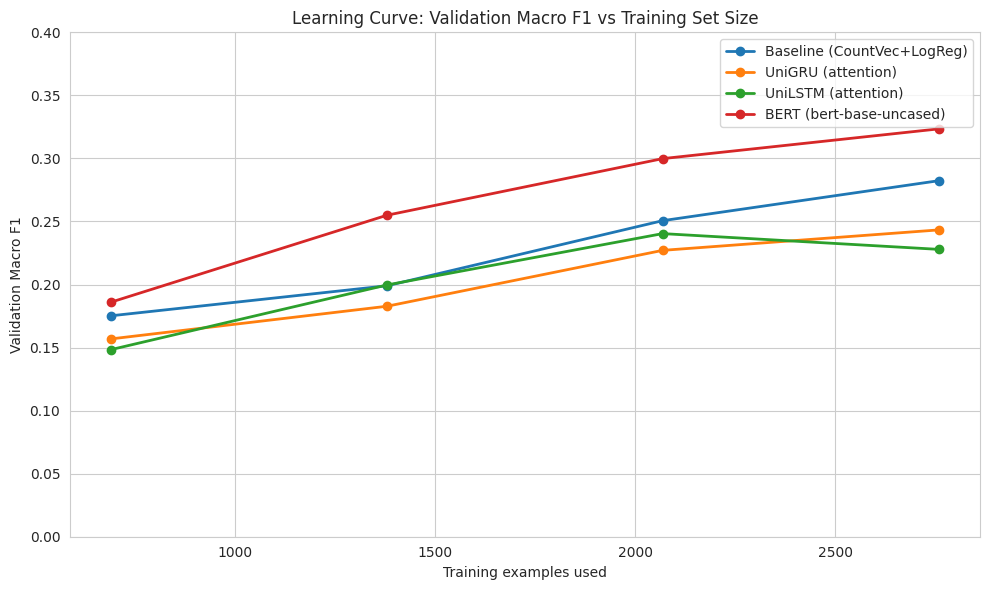

Saved: figures/learning_curve_f1.png


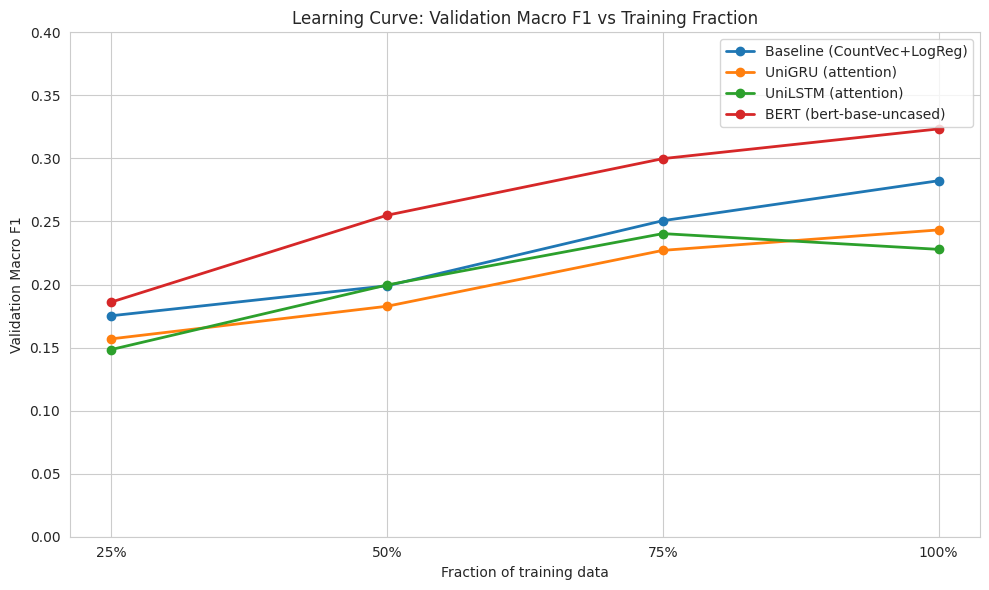

Saved: figures/learning_curve_f1_fraction.png


In [18]:
# ============================
# Save + plot
# ============================
lc_df = pd.DataFrame(all_rows)
lc_df.to_csv("results/learning_curve.csv", index=False)
print("\nSaved: results/learning_curve.csv")

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# x-axis as absolute train size
for model_name in lc_df["Model"].unique():
    sub = lc_df[lc_df["Model"] == model_name].sort_values("Train Size")
    plt.plot(sub["Train Size"], sub["Val Macro F1"], marker="o", linewidth=2, label=model_name)

plt.title("Learning Curve: Validation Macro F1 vs Training Set Size")
plt.xlabel("Training examples used")
plt.ylabel("Validation Macro F1")
plt.ylim(0.0, 0.4)
plt.legend()
plt.tight_layout()
plt.savefig("figures/learning_curve_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/learning_curve_f1.png")

# (Optional) also plot vs fraction to match the prompt exactly
plt.figure(figsize=(10, 6))
for model_name in lc_df["Model"].unique():
    sub = lc_df[lc_df["Model"] == model_name].sort_values("Train Frac")
    plt.plot(sub["Train Frac"], sub["Val Macro F1"], marker="o", linewidth=2, label=model_name)

plt.title("Learning Curve: Validation Macro F1 vs Training Fraction")
plt.xlabel("Fraction of training data")
plt.ylabel("Validation Macro F1")
plt.xticks(SIZES, [f"{int(s*100)}%" for s in SIZES])
plt.ylim(0.0, 0.4)
plt.legend()
plt.tight_layout()
plt.savefig("figures/learning_curve_f1_fraction.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: figures/learning_curve_f1_fraction.png")

In [15]:
f1_table = (
    lc_df.pivot(index="Train Frac", columns="Model", values="Val Macro F1")
      .sort_index()
)

f1_table.index = (f1_table.index.astype(float) * 100).astype(int).astype(str) + "%"

print(f1_table.round(4).to_string())

# optional: save
# f1_table.round(4).to_csv("results/learning_curve_f1_table.csv")

Model       BERT (bert-base-uncased)  Baseline (CountVec+LogReg)  UniGRU (attention)  UniLSTM (attention)
Train Frac                                                                                               
25%                           0.1861                      0.1752              0.1569               0.1485
50%                           0.2550                      0.1990              0.1828               0.1997
75%                           0.2998                      0.2506              0.2271               0.2404
100%                          0.3234                      0.2823              0.2433               0.2279


In [16]:
# ============================
# Quick analysis helpers:
# - When do neural models beat baseline?
# ============================
baseline = lc_df[lc_df["Model"] == "Baseline (CountVec+LogReg)"][["Train Frac", "Val Macro F1"]].set_index("Train Frac")
neural_models = ["UniGRU (attention)", "UniLSTM (attention)", "BERT (bert-base-uncased)"]

print("\n=== Crossover points (first fraction where model >= baseline) ===")
for m in neural_models:
    sub = lc_df[lc_df["Model"] == m][["Train Frac", "Val Macro F1"]].sort_values("Train Frac")
    crossover = None
    for _, r in sub.iterrows():
        b = float(baseline.loc[r["Train Frac"], "Val Macro F1"])
        if r["Val Macro F1"] >= b:
            crossover = r["Train Frac"]
            break
    print(f"{m}: {crossover if crossover is not None else 'never (within tested sizes)'}")


=== Crossover points (first fraction where model >= baseline) ===
UniGRU (attention): never (within tested sizes)
UniLSTM (attention): 0.5
BERT (bert-base-uncased): 0.25
